In [7]:
library(ComplexHeatmap)
library(circlize)
library(ggplot2)
library(tidyr)
library(dplyr)
library(gridExtra)
library(grid)
library(patchwork)
library(ggpubr)

Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.3.2”
Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


Warning message:
“package ‘circlize’ was built under R version 4.3.3”
circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circ

In [2]:
load("/vol/projects/yzhang/500FG_aging/output/20_cellcount_age_trajectory/age_trajectory_nature.Rdata")

In [4]:
cellcount_cor <- read.csv("/vol/projects/yzhang/500FG_aging/output/07_cellcounts/cellcounts_age_rawless_gender_FDR.csv",row.names=1)
head(cellcount_cor)
dim(cellcount_cor)
cellcount_sig <- cellcount_cor[cellcount_cor$sig=="sig",]
head(cellcount_sig)
dim(cellcount_sig)

,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,Granulocytes,0.0053116240,6.575255e-04,1.690205e-02,1.919974e-03,sig
Estimate1,Monocytes (CD14+),0.0027371700,1.226924e-01,2.494061e-03,1.722413e-01,no
Estimate2,Classical monocytes (CD14++CD16-),0.0003365318,8.606286e-01,2.193657e-05,9.105201e-01,no
Estimate3,Non-classical monocytes (CD14++CD16+),0.0106594533,7.996762e-07,6.499160e-02,3.441537e-06,sig
Estimate4,Intermediate monocytes (CD14+CD16+),0.0112041293,2.481781e-08,8.521005e-02,2.013000e-07,sig
Estimate5,T cells (CD3+ CD56-),-0.0056417279,1.308008e-04,-2.190903e-02,4.151505e-04,sig


[1] 73  6

,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,Granulocytes,0.005311624,6.575255e-04,0.01690205,1.919974e-03,sig
Estimate3,Non-classical monocytes (CD14++CD16+),0.010659453,7.996762e-07,0.06499160,3.441537e-06,sig
Estimate4,Intermediate monocytes (CD14+CD16+),0.011204129,2.481781e-08,0.08521005,2.013000e-07,sig
Estimate5,T cells (CD3+ CD56-),-0.005641728,1.308008e-04,-0.02190903,4.151505e-04,sig
Estimate8,B cells (CD19+),-0.006113829,1.576612e-03,-0.01713263,3.836424e-03,sig
Estimate10,CD8+ T cells,-0.010668145,9.747734e-11,-0.10679982,8.894807e-10,sig


[1] 42  6

In [16]:
cellcounts <- read.csv("/vol/projects/yzhang/500FG_aging/input/cellCounts/cellcounts_name_replace.csv",row.names=1,check.names = FALSE)
head(cellcounts)
dim(cellcounts)
cellcounts_info <- read.table("/vol/projects/CIIM/cohorts_old/500FG/Molecular_phenotype/500FG_cellcounts_info.txt")
head(cellcounts_info)
colnames(cellcounts) <- cellcounts_info$finalName[match(colnames(cellcounts), cellcounts_info$trait)]
head(cellcounts)
dim(cellcounts)

,Neutrophils,Monocytes (CD14+),Monocytes (CD14++CD16-),Monocytes (CD14++CD16+),Monocytes (CD14+CD16+),Tc (CD3+ CD56-),NK (CD3- CD56+),NK-T (CD3+ CD56+),B cells (CD19+),T4 (CD4+ CD8-),⋯,IgD- CD5+,IgD+ CD5+,Prol DN(CD4-CD8-),Prol DP(CD4+CD8+),Prol CD4+ Tconv,Prol CD4+ Treg,Prol CD8,Treg CD45RA+,Treg CD45RA-,Treg HLA-DR+
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV003,-0.7045564,-0.4783576,-0.3823108,-0.0522959,-0.1945046,-1.1736302,-2.8877786,-0.32023844,0.01580384,-0.8775032,⋯,-0.1304413,0.41124576,-0.16485366,-0.12063932,0.3023744,-0.7108026,-1.4626983,-0.6798409,-0.9590444,0.1673187
HV004,2.4682104,0.3433585,0.5761697,-0.3614678,-0.4783576,-0.6615738,1.0267065,-0.57904232,0.41124576,-0.5848020,⋯,0.4920324,0.89551086,-0.06690952,-0.14025590,0.2218351,-0.3823108,-0.5336287,0.1623896,0.1623896,0.2468250
HV005,0.2118786,-1.3576090,-1.2549268,-0.5963799,-0.7553342,-0.3927943,0.1230887,0.98635829,0.75857199,-0.8081388,⋯,1.0267065,0.04986147,-0.46748183,0.21685414,-0.2593771,-0.2543515,-1.1736302,-0.6021990,-0.6859803,0.2019431
HV006,-0.6435248,-0.9982921,-0.8014168,-1.0818022,-1.4626983,-0.5336287,-0.6080384,0.01094088,0.15746453,-0.4458936,⋯,-0.5963799,0.19202751,-1.60437056,-1.25492680,-1.0308337,-1.5375801,-1.7648168,-0.3718691,-0.6525227,-0.6021990
HV007,-0.8632995,-1.1736302,-0.8562626,-1.3824671,-1.0994290,-1.6994536,-0.1206393,-1.27659327,-1.12652869,-1.6791979,⋯,-1.5219124,-0.29474822,-2.15658740,-2.10931320,-1.3824671,-2.4200373,-2.5228989,-1.2338339,-2.3377804,-1.1174042
HV008,-0.4620647,-0.6375551,-0.5733018,-1.1083718,-0.7880801,-0.9982921,-0.9361896,0.40068536,-1.08180216,-0.8148976,⋯,0.1821308,-0.85626255,0.12308870,-0.00850951,0.1771891,0.1084030,-0.1994624,-0.4458936,0.3485208,-1.0391412


[1] 515  73

,code,index,stain,trait,cluster,type,finalName,finalSubpopulation,broadSubpopulations,parent,grandpa,FrequencyPlot
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
IT1,IT1,1,Stain 1,Neutrophils,Yes,cellCount,Granulocytes,White blood cells,WBC,NA,NA,1
IT2,IT2,2,Stain 1,Monocytes (CD14+),Yes,cellCount,Monocytes (CD14+),White blood cells,WBC,NA,NA,1
IT3,IT3,3,Stain 1,Monocytes (CD14++CD16-),Yes,cellCount,Classical monocytes (CD14++CD16-),Monocytes,Monocytes,IT2,IT1,NA
IT4,IT4,4,Stain 1,Monocytes (CD14++CD16+),Yes,cellCount,Non-classical monocytes (CD14++CD16+),Monocytes,Monocytes,IT2,IT1,NA
IT5,IT5,5,Stain 1,Monocytes (CD14+CD16+),Yes,cellCount,Intermediate monocytes (CD14+CD16+),Monocytes,Monocytes,IT2,IT1,NA
IT7,IT7,7,Stain 1,Tc (CD3+ CD56-),Yes,cellCount,T cells (CD3+ CD56-),Lymphocytes,Lymphocytes,IT21,NA,NA


,Granulocytes,Monocytes (CD14+),Classical monocytes (CD14++CD16-),Non-classical monocytes (CD14++CD16+),Intermediate monocytes (CD14+CD16+),T cells (CD3+ CD56-),NK cells (CD3- CD56+),NKT cells (CD3+ CD56+),B cells (CD19+),CD4+ T cells,⋯,IgD- CD5+,IgD+ CD5+,Prol DN(CD4-CD8-),Prol DP(CD4+CD8+),Prol CD4+ Tconv,Prol CD4+ Treg,Prol CD8,Treg CD45RA+,Treg CD45RA-,Treg HLA-DR+
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV003,-0.7045564,-0.4783576,-0.3823108,-0.0522959,-0.1945046,-1.1736302,-2.8877786,-0.32023844,0.01580384,-0.8775032,⋯,-0.1304413,0.41124576,-0.16485366,-0.12063932,0.3023744,-0.7108026,-1.4626983,-0.6798409,-0.9590444,0.1673187
HV004,2.4682104,0.3433585,0.5761697,-0.3614678,-0.4783576,-0.6615738,1.0267065,-0.57904232,0.41124576,-0.5848020,⋯,0.4920324,0.89551086,-0.06690952,-0.14025590,0.2218351,-0.3823108,-0.5336287,0.1623896,0.1623896,0.2468250
HV005,0.2118786,-1.3576090,-1.2549268,-0.5963799,-0.7553342,-0.3927943,0.1230887,0.98635829,0.75857199,-0.8081388,⋯,1.0267065,0.04986147,-0.46748183,0.21685414,-0.2593771,-0.2543515,-1.1736302,-0.6021990,-0.6859803,0.2019431
HV006,-0.6435248,-0.9982921,-0.8014168,-1.0818022,-1.4626983,-0.5336287,-0.6080384,0.01094088,0.15746453,-0.4458936,⋯,-0.5963799,0.19202751,-1.60437056,-1.25492680,-1.0308337,-1.5375801,-1.7648168,-0.3718691,-0.6525227,-0.6021990
HV007,-0.8632995,-1.1736302,-0.8562626,-1.3824671,-1.0994290,-1.6994536,-0.1206393,-1.27659327,-1.12652869,-1.6791979,⋯,-1.5219124,-0.29474822,-2.15658740,-2.10931320,-1.3824671,-2.4200373,-2.5228989,-1.2338339,-2.3377804,-1.1174042
HV008,-0.4620647,-0.6375551,-0.5733018,-1.1083718,-0.7880801,-0.9982921,-0.9361896,0.40068536,-1.08180216,-0.8148976,⋯,0.1821308,-0.85626255,0.12308870,-0.00850951,0.1771891,0.1084030,-0.1994624,-0.4458936,0.3485208,-1.0391412


[1] 515  73

In [21]:
saveRDS(cellcounts,"/vol/projects/yzhang/500FG_aging/input/cellCounts/cellcounts_finalname_replace.rds")

In [5]:
cellcount_exp <- cellcounts[, colnames(cellcounts) %in% cellcount_sig$feature]
head(cellcount_exp)
dim(cellcount_exp)

,Granulocytes,Non-classical monocytes (CD14++CD16+),Intermediate monocytes (CD14+CD16+),T cells (CD3+ CD56-),B cells (CD19+),CD8+ T cells,DN (CD4- CD8-),NK bright (CD56++ CD16-),NK (CD56+ CD16-),CD45RO- CD45RA+ T cells,⋯,Natural effector (CD24+ CD38+ IgD+ IgM+),IgD- CD5++,IgD+ CD5++,IgD+ CD5+,Prol DN(CD4-CD8-),Prol DP(CD4+CD8+),Prol CD4+ Tconv,Prol CD4+ Treg,Prol CD8,Treg CD45RA-
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV003,-0.7045564,-0.0522959,-0.1945046,-1.1736302,0.01580384,-1.1736302,-2.0663305,-1.2132762,-0.9361896,-0.21436571,⋯,-0.18460323,0.59928692,0.8319598,0.41124576,-0.16485366,-0.12063932,0.3023744,-0.7108026,-1.4626983,-0.9590444
HV004,2.4682104,-0.3614678,-0.4783576,-0.6615738,0.41124576,-0.5280305,-0.7108026,0.3227987,-0.8148976,-0.01337232,⋯,-0.18955159,1.01036983,0.7521043,0.89551086,-0.06690952,-0.14025590,0.2218351,-0.3823108,-0.5336287,0.1623896
HV005,0.2118786,-0.5963799,-0.7553342,-0.3927943,0.75857199,0.3382052,-0.3562819,0.8597757,1.0103698,-1.28765481,⋯,0.61683679,1.13112629,0.9706617,0.04986147,-0.46748183,0.21685414,-0.2593771,-0.2543515,-1.1736302,-0.6859803
HV006,-0.6435248,-1.0818022,-1.4626983,-0.5336287,0.15746453,-0.4458936,-1.3102636,-0.5733018,-0.5280305,-0.14025590,⋯,-0.06447301,0.35369249,0.6767807,0.19202751,-1.60437056,-1.25492680,-1.0308337,-1.5375801,-1.7648168,-0.6525227
HV007,-0.8632995,-1.3824671,-1.0994290,-1.6994536,-1.12652869,-0.9982921,-1.6994536,-1.8657550,-0.8285281,-0.68598033,⋯,-1.15448199,-0.01337232,0.3074684,-0.29474822,-2.15658740,-2.10931320,-1.3824671,-2.4200373,-2.5228989,-2.3377804
HV008,-0.4620647,-1.1083718,-0.7880801,-0.9982921,-1.08180216,-0.8492678,-1.1450647,-1.8257014,-1.1083718,-0.64352483,⋯,-0.16485366,-0.69214579,-1.1640028,-0.85626255,0.12308870,-0.00850951,0.1771891,0.1084030,-0.1994624,0.3485208


[1] 515  42

In [24]:
pheno <- read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/Age_group_basicPhenos.csv",row.names=1)
rownames(pheno) <- pheno$ID_500fg
head(pheno)

,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
HV043,HV043,male,18,182,50,15.09480,Married,University student,European,Rarely,Yes,Yes,16,12,346,2013,Group 1
HV515,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
HV518,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
HV314,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
HV497,HV497,female,18,157,49,19.87910,Married,Hogeschool opleiding (HBO),Asian,Rarely,No,No,24,11,324,2014,Group 1
HV454,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1


agg_record_207245153 
                   2

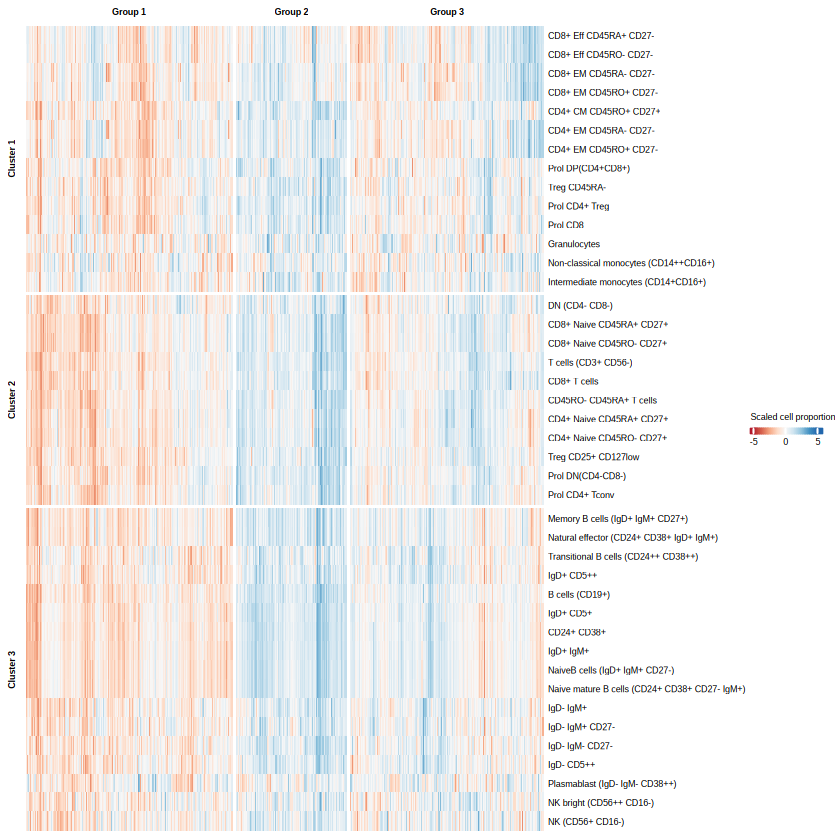

In [8]:
mat <- as.matrix(t(cellcount_exp))
# Scale by row (each cell type scaled across individuals)
mat_scaled <- t(scale(t(mat)))

# ------------------------------------------------------------------------------
# 2. Cluster columns (individuals) -> Group 1, 2, 3 (immunotype)
# ------------------------------------------------------------------------------
hc_col <- hclust(dist(t(mat_scaled), method = "euclidean"), method = "ward.D2")
immunotype <- cutree(hc_col, k = 3)
group_label <- factor(paste0("Group ", immunotype[colnames(mat)]), levels = paste0("Group ", 1:3))

# ------------------------------------------------------------------------------
# 3. Cluster rows (cell types) -> C1, C2, C3
# ------------------------------------------------------------------------------
hc_row <- hclust(dist(mat_scaled, method = "euclidean"), method = "ward.D2")
feature_cluster <- cutree(hc_row, k = 3)

# ------------------------------------------------------------------------------
# 4. Heatmap colors: scaled proportion -5 to 5 (blue-white-red)
# ------------------------------------------------------------------------------
col_fun <- colorRamp2(
  seq(-5, 5, length.out = 9),
  rev(c("#2166ac", "#4393c3", "#92c5de", "#d1e5f0", "#f7f7f7", "#fddbc7", "#f4a582", "#d6604d", "#b2182b"))
)

# ------------------------------------------------------------------------------
# 5. Draw heatmap (rows = features, cols = individuals); Group 1/2/3 as column titles
# ------------------------------------------------------------------------------
ht <- Heatmap(
  mat_scaled,
  name = "Scaled cell proportion",
  cluster_rows = hc_row,
  cluster_columns = hc_col,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
  row_split = 3,
  column_split = 3,
  column_title = c("Group 1", "Group 2", "Group 3"),
  column_title_gp = gpar(fontsize = 5, fontface = "bold"),
  show_column_names = FALSE,
  show_row_names = TRUE,
  # show_row_names = FALSE,
  row_title = c("Cluster 1", "Cluster 2", "Cluster 3"),
  row_title_gp = gpar(fontsize = 5, fontface = "bold"),
  col = col_fun,
  row_names_gp = gpar(fontsize = 5),
  column_names_gp = gpar(fontsize = 5),
  heatmap_legend_param = list(
    title_gp = gpar(fontsize = 5),
    labels_gp = gpar(fontsize = 5),
    direction = "horizontal",
    legend_width = unit(1.5, "cm"),
    grid_height = unit(1, "mm") 
  )
)

# 62 mm -> inches (1 inch = 25.4 mm)
pdf("/vol/projects/yzhang/500FG_aging/output/20_cellcount_age_trajectory/cellcount_age_trajectory_heatmap_gender.pdf", width = 88/25.4, height = 80/25.4)
draw(ht, heatmap_legend_side = "bottom")
dev.off()

draw(ht, newpage = TRUE)

agg_record_10984765 
                  2

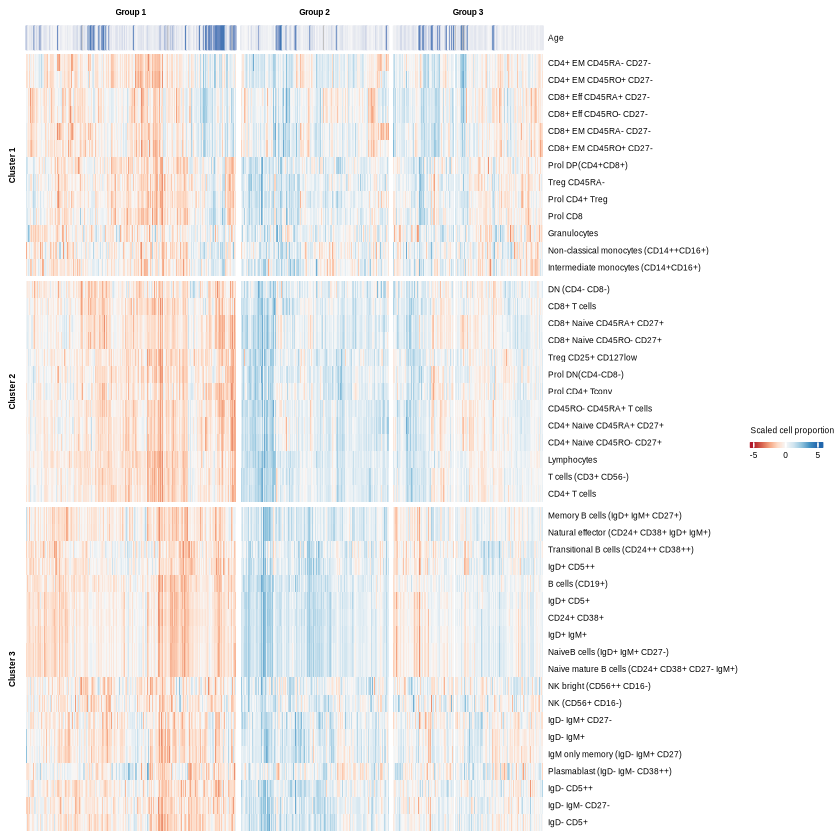

In [86]:
top_anno <- HeatmapAnnotation(
  Age = anno_simple(
    age_vec,
    col = colorRamp2(
      range(age_vec, na.rm = TRUE),
      c("#f7f7f7", "#2166ac")
    )
  ),
  annotation_name_gp = gpar(fontsize = 5)
  # no annotation_legend_param
)

# Add top_annotation in Heatmap()
ht <- Heatmap(
  mat_scaled,
  name = "Scaled cell proportion",
  top_annotation = top_anno,   # add this line
  cluster_rows = hc_row,
  cluster_columns = hc_col,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
  row_split = 3,
  column_split = 3,
  column_title = c("Group 1", "Group 2", "Group 3"),
  column_title_gp = gpar(fontsize = 5, fontface = "bold"),
  show_column_names = FALSE,
  show_row_names = TRUE,
  # show_row_names = FALSE,
  row_title = c("Cluster 1", "Cluster 2", "Cluster 3"),
  row_title_gp = gpar(fontsize = 5, fontface = "bold"),
  col = col_fun,
  row_names_gp = gpar(fontsize = 5),
  column_names_gp = gpar(fontsize = 5),
  heatmap_legend_param = list(
    title_gp = gpar(fontsize = 5),
    labels_gp = gpar(fontsize = 5),
    direction = "horizontal",
    legend_width = unit(1.5, "cm"),
    grid_height = unit(1, "mm") 
  )
)

pdf("/vol/projects/yzhang/500FG_aging/output/20_cellcount_age_trajectory/cellcount_age_trajectory_heatmap_age.pdf", width = 88/25.4, height = 80/25.4)
draw(ht, heatmap_legend_side = "bottom")
dev.off()

draw(ht, newpage = TRUE)

In [9]:
df_age <- data.frame(
  age   = age_vec,
  group = group_label
)

aggregate(age ~ group, data = df_age, FUN = function(x) c(
  n = length(x),
  mean = mean(x, na.rm = TRUE),
  sd   = sd(x, na.rm = TRUE),
  median = median(x, na.rm = TRUE),
  IQR   = IQR(x, na.rm = TRUE)
))


# One-way ANOVA (assumes normality and similar variances)
fit_aov <- aov(age ~ group, data = df_age)
summary(fit_aov)
kruskal.test(age ~ group, data = df_age)

# 3. Pairwise comparisons (optional)
# Wilcoxon rank-sum test for each pair, with BH correction
pairwise.wilcox.test(df_age$age, df_age$group, p.adjust.method = "BH", exact = FALSE)


group,age
<fct>,"<dbl[,5]>"
Group 1,"192, 27.27604, 12.62806, 23, 6.0"
Group 2,"207, 30.80193, 15.32732, 24, 8.5"
Group 3,"109, 26.00000, 11.47057, 22, 4.0"


             Df Sum Sq Mean Sq F value  Pr(>F)   
group         2   2064  1031.9     5.6 0.00393 **
Residuals   505  93063   184.3                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
7 observations deleted due to missingness


	Kruskal-Wallis rank sum test

data:  age by group
Kruskal-Wallis chi-squared = 13.147, df = 2, p-value = 0.001397



	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  df_age$age and df_age$group 

        Group 1 Group 2
Group 2 0.0070  -      
Group 3 0.3968  0.0039 

P value adjustment method: BH 

Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_ydensity()`).”
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_ydensity()`).”
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_boxplot()`).”


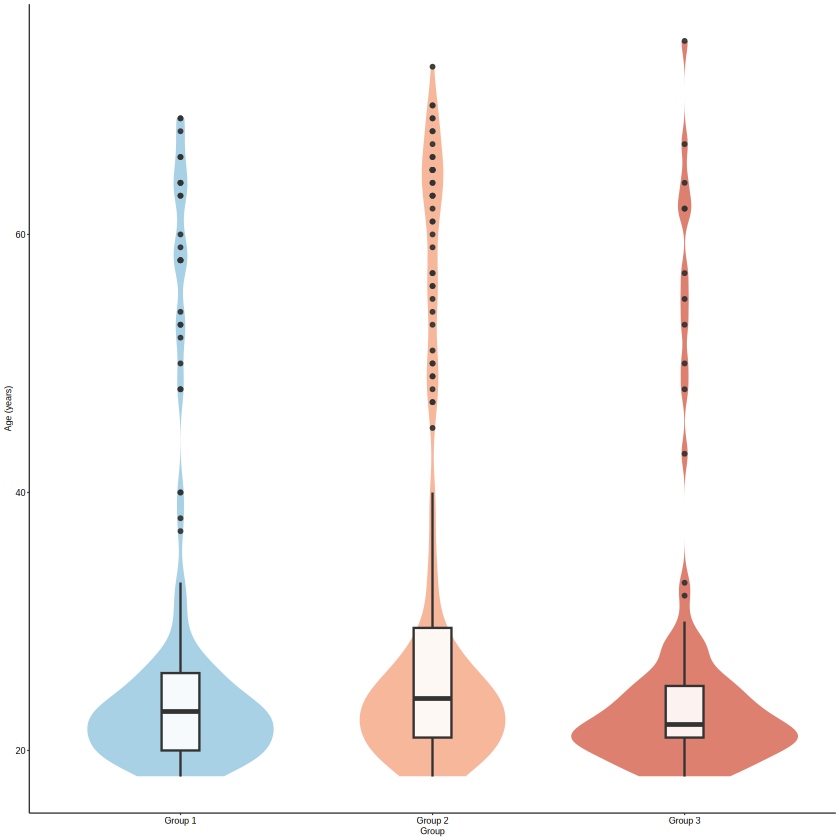

In [13]:
p <- ggplot(df_age, aes(x = group, y = age, fill = group)) +
  geom_violin(alpha = 0.8, color = NA) +
  geom_boxplot(width = 0.15, fill = "white", outlier.size = 0.6, alpha = 0.9) +
  scale_fill_manual(values = c("Group 1" = "#92c5de", "Group 2" = "#f4a582", "Group 3" = "#d6604d")) +
  labs(
    x = "Group",
    y = "Age (years)"
  ) +
  theme_classic(base_size = 5) +
  theme(
    legend.position = "none",
    plot.title = element_text(hjust = 0.5, face = "bold", size = 5),
    axis.title = element_text(size = 5),
    axis.text = element_text(color = "black", size = 5),
    axis.ticks = element_line(linewidth = 0.25)
  )

p_sig <- p + stat_compare_means(
  comparisons = list(
    c("Group 1", "Group 2"),
    c("Group 1", "Group 3"),
    c("Group 2", "Group 3")
  ),
  method = "wilcox.test",
  label = "p.signif",
  tip.length = 0.02,
  size = 2.2   # bracket/label size relative to base (adjust if asterisks too small)
)

# Save PDF: 80 mm x 42 mm (1 inch = 25.4 mm)
ggsave(
  "/vol/projects/yzhang/500FG_aging/output/20_cellcount_age_trajectory/age_by_group_violin2_gender.pdf",
  plot = p_sig,
  width = 70 / 25.4,
  height = 47 / 25.4,
  units = "in",
  device = "pdf"
)
print(p)

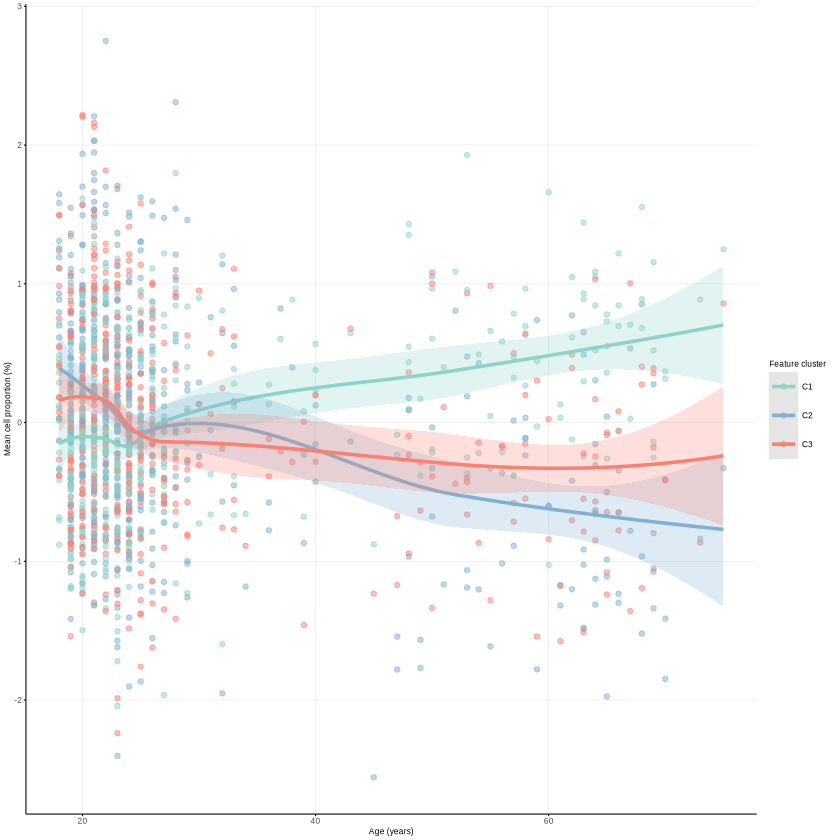

In [77]:
# Feature cluster: map cell type -> C1/C2/C3 (from heatmap row clustering; rownames(mat) = cell types)
fc_vec_feature <- setNames(paste0("C", feature_cluster), rownames(mat))

# Raw proportion matrix: rows = individuals, cols = cell types (use cellcount_exp, not mat)
mat_raw <- as.matrix(cellcount_exp)

# Per-individual mean proportion per feature cluster.
# If cellcount_exp is in 0-1 (proportion), use *100 to get %; if already 0-100 (%), do not multiply.
# Check: if max value in data > 1.5, assume already in %.
already_pct <- max(mat_raw, na.rm = TRUE) > 1.5
cluster_means <- mat_raw %>%
  as.data.frame() %>%
  tibble::rownames_to_column("individual") %>%
  pivot_longer(-individual, names_to = "cell_type", values_to = "proportion") %>%
  mutate(feature_cluster = fc_vec_feature[.data$cell_type]) %>%
  filter(!is.na(.data$feature_cluster)) %>%
  group_by(individual, feature_cluster) %>%
  summarise(mean_prop = mean(proportion, na.rm = TRUE) * if (already_pct) 1 else 100, .groups = "drop")

# Add age; drop missing age
age_vec_traj <- setNames(pheno[rownames(mat_raw), "Age"], rownames(mat_raw))
traj_df <- cluster_means %>%
  mutate(Age = age_vec_traj[.data$individual]) %>%
  filter(is.finite(.data$Age)) %>%
  mutate(feature_cluster = factor(.data$feature_cluster, levels = c("C1", "C2", "C3")))

# Nature-style colors (colorblind-friendly, distinct)
# cluster_colors <- c("C1" = "#0173b2", "C2" = "#029e73", "C3" = "#de8f05")
 # cluster_colors <- c("C1" = "#0EA5E9", "C2" = "#10B981", "C3" = "#F59E0B")
# cluster_colors <- c("C1" = "#0072B2", "C2" = "#009E73", "C3" = "#D55E00")
cluster_colors <- c("C1" = "#8DD3C7", "C2" = "#80B1D3", "C3" = "#FB8072")
# One panel: 3 LOESS curves (C1, C2, C3 vs age)
# Y-axis: "Mean cell proportion (%)" = mean proportion of cells in that cluster, in percent (correct)
p_traj <- ggplot(traj_df, aes(x = Age, y = mean_prop, color = feature_cluster, fill = feature_cluster)) +
  geom_point(alpha = 0.5, size = 1.2) +
  geom_smooth(method = "loess", formula = y ~ x, se = TRUE, linewidth = 1, alpha = 0.25) +
  scale_color_manual(values = cluster_colors, name = "Feature cluster") +
  scale_fill_manual(values = cluster_colors, name = "Feature cluster", guide = "none") +
  labs(x = "Age (years)", y = "Mean cell proportion (%)") +
  theme_minimal(base_size = 5) +
  theme(
    legend.position = "right",
    panel.grid.minor = element_blank(),
    axis.line = element_line(linewidth = 0.3),
    axis.ticks = element_line(linewidth = 0.3),
    axis.title = element_text(size = 5),
    axis.text = element_text(size = 5),
    legend.title = element_text(size = 5),
    legend.text = element_text(size = 5)
  )
print(p_traj)            
# 85 mm -> inches
ggsave("/vol/projects/yzhang/500FG_aging/output/20_cellcount_age_trajectory/age_trajectory_C1_C2_C3.pdf", p_traj, width = 85/25.4, height = 60/25.4)


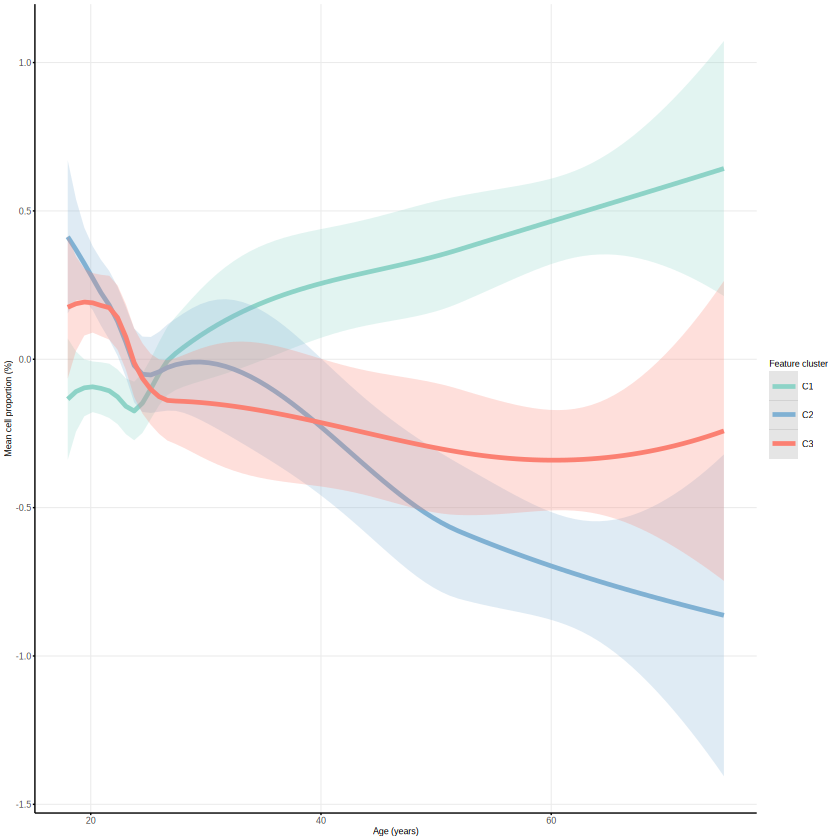

In [11]:
# Feature cluster: map cell type -> C1/C2/C3 (from heatmap row clustering; rownames(mat) = cell types)
fc_vec_feature <- setNames(paste0("C", feature_cluster), rownames(mat))

# Raw proportion matrix: rows = individuals, cols = cell types (use cellcount_exp, not mat)
mat_raw <- as.matrix(cellcount_exp)

# Per-individual mean proportion per feature cluster.
# If cellcount_exp is in 0-1 (proportion), use *100 to get %; if already 0-100 (%), do not multiply.
# Check: if max value in data > 1.5, assume already in %.
already_pct <- max(mat_raw, na.rm = TRUE) > 1.5
cluster_means <- mat_raw %>%
  as.data.frame() %>%
  tibble::rownames_to_column("individual") %>%
  pivot_longer(-individual, names_to = "cell_type", values_to = "proportion") %>%
  mutate(feature_cluster = fc_vec_feature[.data$cell_type]) %>%
  filter(!is.na(.data$feature_cluster)) %>%
  group_by(individual, feature_cluster) %>%
  summarise(mean_prop = mean(proportion, na.rm = TRUE) * if (already_pct) 1 else 100, .groups = "drop")
# Nature-style colors (colorblind-friendly, distinct)
cluster_colors <- c("C1" = "#8DD3C7", "C2" = "#80B1D3", "C3" = "#FB8072")
# Add age; drop missing age
age_vec_traj <- setNames(pheno[rownames(mat_raw), "Age"], rownames(mat_raw))
traj_df <- cluster_means %>%
  mutate(Age = age_vec_traj[.data$individual]) %>%
  filter(is.finite(.data$Age)) %>%
  mutate(feature_cluster = factor(.data$feature_cluster, levels = c("C1", "C2", "C3")))
            
p_traj <- ggplot(traj_df, aes(x = Age, y = mean_prop, color = feature_cluster, fill = feature_cluster)) +
  geom_smooth(method = "loess", formula = y ~ x, se = TRUE, linewidth = 1, alpha = 0.25) +
  scale_color_manual(values = cluster_colors, name = "Feature cluster") +
  scale_fill_manual(values = cluster_colors, name = "Feature cluster", guide = "none") +
  labs(x = "Age (years)", y = "Mean cell proportion (%)") +
  theme_minimal(base_size = 5) +
  theme(
    legend.position = "right",
    panel.grid.minor = element_blank(),
    axis.line = element_line(linewidth = 0.3),
    axis.ticks = element_line(linewidth = 0.3),
    axis.title = element_text(size = 5),
    axis.text = element_text(size = 5),
    legend.title = element_text(size = 5),
    legend.text = element_text(size = 5)
  )
print(p_traj)
ggsave("/vol/projects/yzhang/500FG_aging/output/20_cellcount_age_trajectory/cellcount_age_trajectory_gender.pdf", p_traj, width = 85/25.4, height = 42/25.4)

In [12]:
save.image("/vol/projects/yzhang/500FG_aging/output/20_cellcount_age_trajectory/age_trajectory_nature_gender.Rdata")